In [2]:
import pandas as pd

In [3]:
customer = pd.read_csv(r'../data\olist_customers_dataset.csv')
orders = pd.read_csv(r'../data\olist_orders_dataset.csv')
payments = pd.read_csv(r'../data\olist_order_payments_dataset.csv')
items = pd.read_csv(r'../data\olist_order_items_dataset.csv')
products = pd.read_csv(r'../data\olist_products_dataset.csv')

In [4]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"])
orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

In [5]:
df = (orders.merge(customer, on= "customer_id").merge(payments, on="order_id").merge(items, on= "order_id"))

In [19]:
print("Общая выручка: {} ".format(df['payment_value'].sum()))

Общая выручка: 20308134.71 


In [20]:
print("Кол-во заказов: {} ".format(df['order_id'].nunique()))

Кол-во заказов: 98665 


In [22]:
print("Кол-во покупателей: {} ".format(df['customer_unique_id'].nunique()))

Кол-во покупателей: 95419 


In [26]:
print("Средний чек: {} ".format(round(df['payment_value'].sum() / df['order_id'].nunique(),2)))

Средний чек: 205.83 


In [ ]:
# Кол-во заказов по месяцам

In [33]:
orders_monthly = (df.groupby(pd.Grouper(key="order_purchase_timestamp", freq="ME"))["order_id"].nunique())

In [34]:
orders_monthly

order_purchase_timestamp
2016-09-30       2
2016-10-31     308
2016-11-30       0
2016-12-31       1
2017-01-31     789
2017-02-28    1733
2017-03-31    2641
2017-04-30    2391
2017-05-31    3660
2017-06-30    3217
2017-07-31    3969
2017-08-31    4293
2017-09-30    4243
2017-10-31    4568
2017-11-30    7451
2017-12-31    5624
2018-01-31    7220
2018-02-28    6694
2018-03-31    7188
2018-04-30    6934
2018-05-31    6853
2018-06-30    6160
2018-07-31    6273
2018-08-31    6452
2018-09-30       1
Freq: ME, Name: order_id, dtype: int64

In [ ]:
# Выручка по месяцам

In [35]:
revenue_monthly = (df.groupby(pd.Grouper(key="order_purchase_timestamp", freq="ME"))["payment_value"].sum())

In [36]:
revenue_monthly

order_purchase_timestamp
2016-09-30        347.52
2016-10-31      73914.58
2016-11-30          0.00
2016-12-31         19.62
2017-01-31     187779.41
2017-02-28     344134.79
2017-03-31     526961.66
2017-04-30     505665.53
2017-05-31     724504.55
2017-06-30     600753.27
2017-07-31     737293.08
2017-08-31     870105.90
2017-09-30    1015849.57
2017-10-31    1021169.27
2017-11-30    1583869.01
2017-12-31    1042855.86
2018-01-31    1408365.65
2018-02-28    1306048.80
2018-03-31    1475599.95
2018-04-30    1496811.52
2018-05-31    1506974.84
2018-06-30    1297594.81
2018-07-31    1351705.34
2018-08-31    1229643.72
2018-09-30        166.46
Freq: ME, Name: payment_value, dtype: float64

<Axes: xlabel='order_purchase_timestamp'>

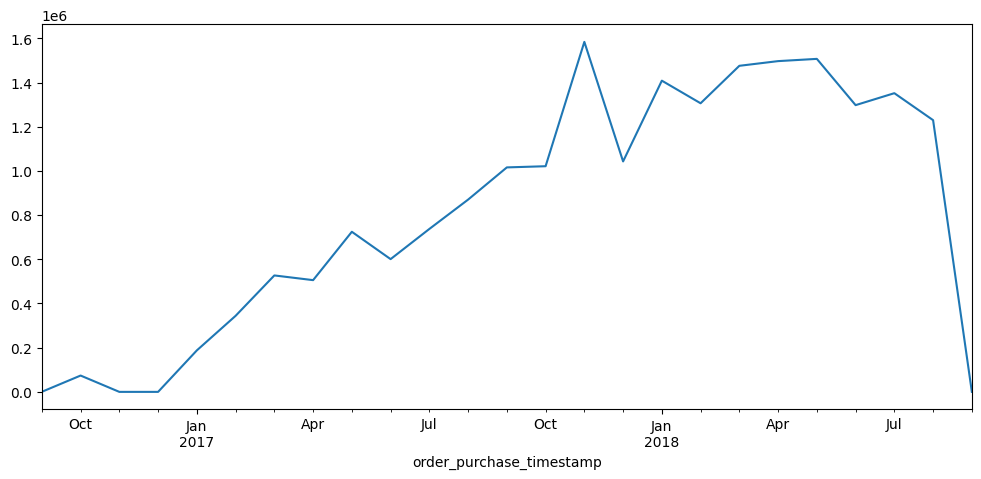

In [39]:
revenue_monthly.plot(figsize=(12,5))